# Diabetes Risk Factor Analysis
## Reproducibility Exercise — Starter Notebook

You are a **data scientist at a teaching hospital within a multi-site academic health system**. This preliminary analytical notebook was originally developed for internal exploratory analysis. The **Data Science Director** has asked you to prepare the notebook and supporting files for sharing with the data science team at another clinical site.

The receiving team should be able to obtain the project files, understand the workflow, execute the notebook in its own computational environment, and reproduce the intended results **without contacting you for additional guidance**.

Review the entire notebook, address all embedded **DATA SCIENCE DIRECTOR NOTE** items, identify and resolve additional reproducibility problems, improve the documentation and organization, and verify the final workflow from a clean runtime.

#### Connection to Upcoming Coursework and Final Project

This exercise is an important step in the development of your final project workflow. The reproducibility, documentation, notebook organization, and programming practices you apply in this assignment will build upon your prior Python programming work and serve as a foundation for the Week 3 Automated Analysis Pipeline Exploration assignment.

In Week 3, you will work with a more advanced automated analytical pipeline that incorporates conditional logic, inferential statistical methods, supervised machine learning, model evaluation, and automated analytical decision-making. Many of the practices reinforced in this exercise—including modular programming, reproducible execution, clear Markdown documentation, dependency management, data validation, and logical workflow organization—will be expected in that assignment.

Your work across these assignments will also inform the development of your final project notebook, in which you will adapt and extend a comprehensive example analytical pipeline for your selected dataset.

Complete this exercise thoroughly and with your final project in mind. The goal is not simply to correct the issues identified in the starter notebook, but to develop programming, documentation, and reproducibility practices that you can carry forward into increasingly complex analytical workflows throughout the remainder of the course.

---

***** DATA SCIENCE DIRECTOR NOTE *****

This notebook will be shared with the data science team at one of our other clinical sites. They will not have access to your current computational environment or any undocumented setup steps.

Please prepare the notebook and supporting project files so that their team can obtain the repository, follow the documentation, execute the complete workflow, and reproduce the current analytical results without needing to contact you for additional instructions. The notebook should also be sufficiently documented and organized so that the receiving team can use the workflow as a template for conducting a similar analysis with patient data from their own clinical site.

I have also left several notes throughout the notebook identifying changes or additions that need to be addressed before the project is shared.

---

## Setup and Environment

This analysis was developed and tested in Google Colab using Python. The workflow requires the following Python packages:

- `pandas` 2.2.3 — data loading, manipulation, and descriptive analysis
- `numpy` 2.1.3 — numerical operations
- `matplotlib` 3.10.0 — data visualization
- `seaborn` 0.13.2 — correlation heatmap visualization
- `scipy` 1.16.3 — inferential statistical tests

The package versions listed above represent the environment used to execute and verify this analysis. Recording these versions helps another clinical site reproduce the computational environment if differences between package versions affect results.

The required dependencies are also documented in the accompanying `requirements.txt` file. They can be installed using:

`pip install -r requirements.txt`

After the required packages are installed, the notebook should be executed sequentially from top to bottom. The workflow is designed to load the diabetes dataset from the documented data source, validate its expected structure, perform the analyses, and reproduce the reported results from a clean runtime.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import ttest_ind, mannwhitneyu

## Data Source

This analysis uses the `Example Dataset_Diabetes.csv` dataset provided for this project. The dataset contains patient-level clinical measurements and a binary diabetes outcome used to explore factors associated with diabetes status. It serves as the primary data source for the descriptive, inferential, and exploratory analyses performed in this notebook.

To improve reproducibility, the dataset is accessed directly from the project repository using a URL rather than from a local file path. This allows the notebook to load the data automatically without requiring users to manually download or upload the CSV file.

The code below reads the dataset directly into a pandas DataFrame. An internet connection is required to retrieve the dataset. If the dataset URL or file location changes in the future, the `DATA_URL` variable must be updated before running the analysis.

In [2]:
DATA_URL = "https://raw.githubusercontent.com/camitor/HSE-751-Reproducibility-Exercise/refs/heads/main/Example%20Dataset_Diabetes.csv"
df = pd.read_csv(DATA_URL)
df.head()

,Pregnancies,Glucose,D_BP,Skin_Thickness,Insulin,BMI,Pedigree,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## Initial Data Review

Before beginning the analysis, the dataset is reviewed to confirm that it loaded successfully and contains the expected structure. This step examines the dataset dimensions, column names, missing values, and data types.

Validation checks are also performed to confirm that the dataset is not empty and contains the expected variables. These checks help identify data-loading or structural problems before continuing with descriptive statistics and further analysis.

In [3]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isna().sum())

print("\nData types:")
print(df.dtypes)

Shape: (768, 9)

Columns:
['Pregnancies', 'Glucose', 'D_BP', 'Skin_Thickness', 'Insulin', 'BMI', 'Pedigree', 'Age', 'Outcome']

Missing values:
Pregnancies       0
Glucose           0
D_BP              0
Skin_Thickness    0
Insulin           0
BMI               0
Pedigree          0
Age               0
Outcome           0
dtype: int64

Data types:
Pregnancies         int64
Glucose             int64
D_BP                int64
Skin_Thickness      int64
Insulin             int64
BMI               float64
Pedigree          float64
Age                 int64
Outcome             int64
dtype: object


In [4]:
# Validate expected dataset structure
expected_columns = ["Pregnancies",
                    "Glucose",
                    "D_BP",
                    "Skin_Thickness",
                    "Insulin",
                    "BMI",
                    "Pedigree",
                    "Age",
                    "Outcome"]

assert not df.empty, "Dataset is empty" # Dataset must contain data, if not, stop
assert list(df.columns) == expected_columns, "Unexpected dataset structure" # Must contain columns expected
print("Dataset validation passed.")

Dataset validation passed.


## Descriptive Statistics

In [5]:
df.describe()

,Pregnancies,Glucose,D_BP,Skin_Thickness,Insulin,BMI,Pedigree,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


### Mean and Standard Deviation

Descriptive statistics are used to summarize the patient characteristics in the diabetes dataset. The mean provides the average value of each numeric variable across the patients in the dataset. For example, mean values for glucose, blood pressure (`D_BP`), BMI, insulin, and age provide an overview of the typical measurements observed in this patient population.

The sample mean is calculated as:

$$
\bar{x} = \frac{1}{n}\sum_{i=1}^{n} x_i
$$

where:

- $\bar{x}$ = sample mean
- $x_i$ = each individual patient observation
- $n$ = total number of patient observations

The standard deviation describes how much patient measurements vary around their respective means:

$$
s = \sqrt{\frac{\sum_{i=1}^{n}(x_i-\bar{x})^2}{n-1}}
$$

where:

- $s$ = sample standard deviation
- $x_i$ = each individual observation
- $\bar{x}$ = sample mean
- $n$ = total number of observations

A smaller standard deviation indicates that patient measurements are more closely clustered around the mean, while a larger standard deviation indicates greater variability among patients.

In this dataset, the 768 patient observations have a mean glucose measurement of approximately **120.9** with a standard deviation of **32.0**, while mean BMI is approximately **32.0** with a standard deviation of **7.9**. Insulin shows considerably greater variability, with a mean of approximately **79.8** and a standard deviation of **115.2**. Patient age averages approximately **33.2 years** with a standard deviation of **11.8 years**. These results demonstrate that the amount of variability differs substantially across patient characteristics and should be considered when examining potential diabetes risk factors.

Because `Outcome` is coded as 0 for no diabetes and 1 for diabetes, its mean of approximately **0.349** also indicates that approximately **34.9%** of the patient observations have a diabetes outcome.

The descriptive statistics also show minimum values of zero for several clinical variables, including glucose, blood pressure (`D_BP`), skin thickness, insulin, and BMI. Some of these zero values may represent missing or invalid clinical measurements rather than true physiological values. Because no documented rule was provided for interpreting or replacing these values, they are retained in the current analysis rather than modified without justification.

## Visualizations

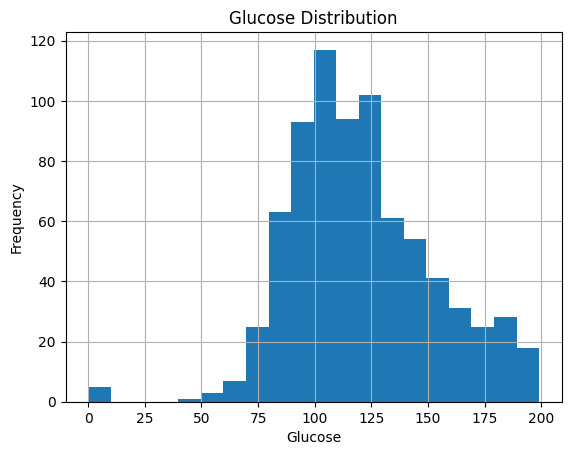

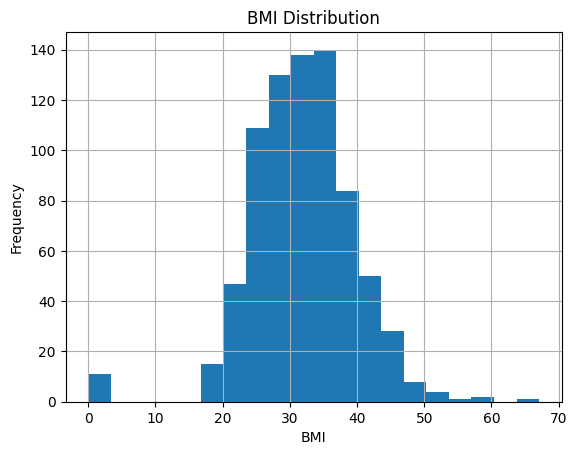

In [6]:
df["Glucose"].hist(bins=20)
plt.title("Glucose Distribution")
plt.xlabel("Glucose")
plt.ylabel("Frequency")
plt.show()

df["BMI"].hist(bins=20)
plt.title("BMI Distribution")
plt.xlabel("BMI")
plt.ylabel("Frequency")
plt.show()

### Glucose levels by diabetes outcome

Patients with the diabetes outcome had higher glucose measurements than patients without the diabetes outcome. The median glucose level was 140 for patients with diabetes compared with 107 for patients without diabetes, while the respective means were approximately 141.3 and 110.0. Although the distributions overlap, the boxplot shows that glucose values were generally higher among patients with the diabetes outcome.

<Figure size 800x600 with 0 Axes>

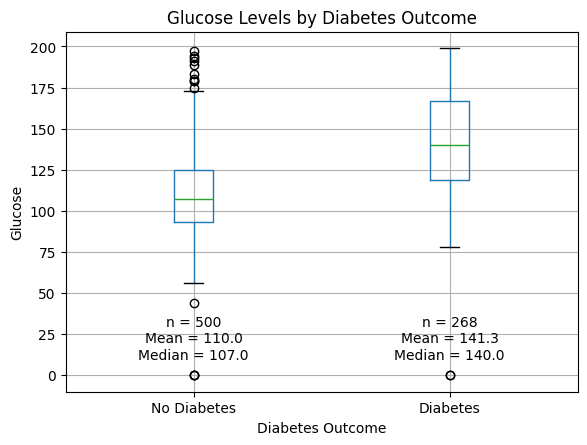

In [7]:
# Compare glucose levels by diabetes outcome
plt.figure(figsize=(8,6))

df.boxplot(column="Glucose", by="Outcome")

plt.title("Glucose Levels by Diabetes Outcome")
plt.suptitle("")
plt.xlabel("Diabetes Outcome")
plt.ylabel("Glucose")

# Replace 0 and 1 with descriptive labels
plt.xticks([1, 2], ["No Diabetes", "Diabetes"])


# Calculate descriptive statistics by outcome
glucose_stats = df.groupby("Outcome")["Glucose"].agg(["count", "mean", "median"])

# Add statistics to the graph
for outcome in [0, 1]:
    stats = glucose_stats.loc[outcome]

    plt.text(
        outcome + 1,
        10,
        f"n = {int(stats['count'])}\nMean = {stats['mean']:.1f}\nMedian = {stats['median']:.1f}",
        ha="center"
    )

plt.show()


### BMI and glucose scatterplot

The scatterplot shows a weak positive linear relationship between BMI and glucose, with a Pearson correlation coefficient of $r = 0.22$. As BMI increases, glucose levels tend to increase slightly; however, the wide spread of observations around the line of best fit indicates substantial variability in this dataset. Several observations with BMI or glucose values of zero are also visible and may represent missing or invalid clinical measurements. Because no documented rule was provided for interpreting these values, they are retained in the current analysis. This relationship is correlational and does not indicate that higher BMI causes higher glucose levels.

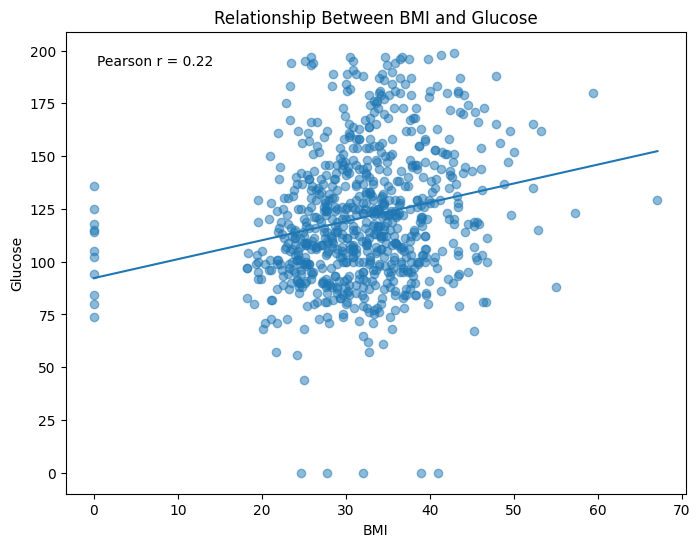

In [8]:
# BMI vs. Glucose scatterplot
fig, ax = plt.subplots(figsize=(8, 6))

plt.scatter(
    df["BMI"],
    df["Glucose"],
    alpha=0.5
)

# Calculate line of best fit
slope, intercept = np.polyfit(df["BMI"], df["Glucose"], 1)

x_line = np.linspace(df["BMI"].min(), df["BMI"].max(), 100)
y_line = slope * x_line + intercept

plt.plot(x_line, y_line)

# Calculate Pearson correlation
r = df["BMI"].corr(df["Glucose"])

plt.text(
    0.05,
    0.95,
    f"Pearson r = {r:.2f}",
    transform=ax.transAxes,
    verticalalignment="top"
)

plt.title("Relationship Between BMI and Glucose")
plt.xlabel("BMI")
plt.ylabel("Glucose")

plt.show()

### Correlation Analysis

Spearman's rank correlation was used to examine relationships among the numerical patient characteristics in this dataset. Spearman correlation was selected instead of Pearson correlation because several variables contain outliers, skewed distributions, and potentially invalid zero values, and the relationships between variables may not be strictly linear. Spearman's method uses ranked observations and evaluates monotonic relationships, making it less sensitive to extreme values and appropriate for this exploratory analysis.

The binary diabetes `Outcome` variable was excluded from the correlation matrix because this analysis focuses on relationships among numerical patient characteristics. Relationships involving `Outcome` are examined separately using visualizations appropriate for a binary outcome.

The strongest positive relationship observed was between `Pregnancies` and `Age` ($r_s = 0.61$), indicating that patients with a greater number of pregnancies tended to be older. `Skin_Thickness` and `Insulin` also showed a moderate positive relationship ($r_s = 0.54$), while `Skin_Thickness` and `BMI` had a moderate positive relationship ($r_s = 0.44$). A weaker positive relationship was observed between blood pressure (`D_BP`) and `Age` ($r_s = 0.35$).

Most other variable pairs demonstrated relatively weak relationships. For example, `Glucose` and `BMI` had a weak positive Spearman correlation ($r_s = 0.23$). This is consistent with the weak positive pattern observed in the previous `BMI` and `Glucose` scatterplot, where the Pearson correlation was similar ($r = 0.22$).

Overall, the correlation analysis helps describe how patient characteristics vary together within this dataset. The observed associations may help guide subsequent exploratory or predictive analyses. However, correlation describes statistical association and does not establish that changes in one patient characteristic cause changes in another.

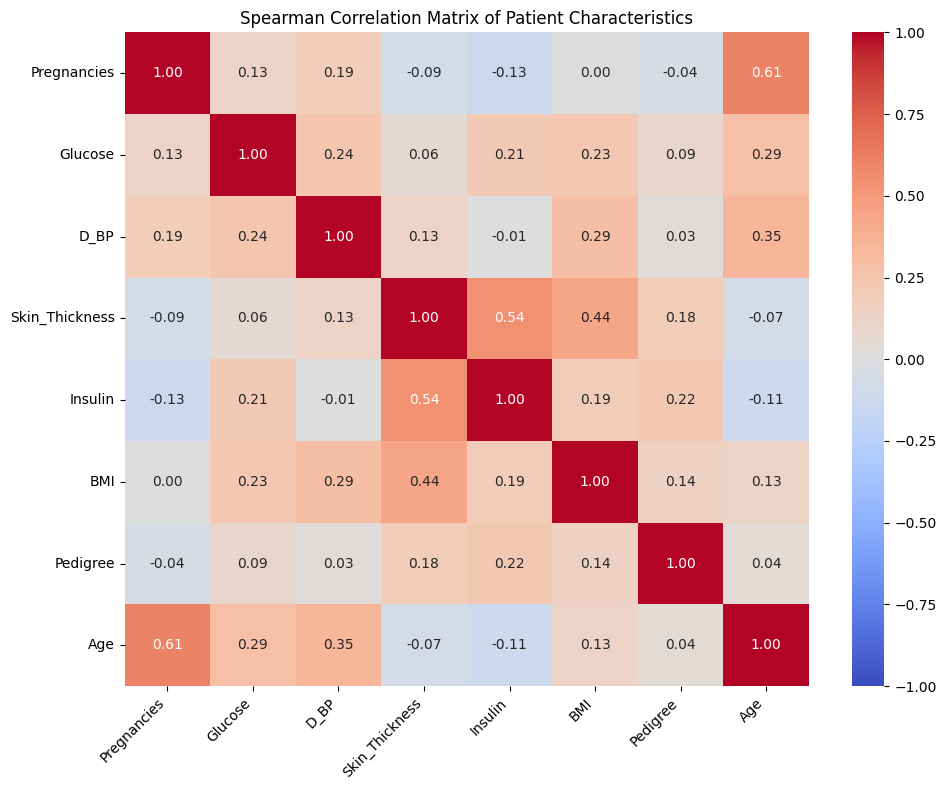

In [9]:
# Corr_matrix for heatmap
correlation_variables = [
    "Pregnancies",
    "Glucose",
    "D_BP",
    "Skin_Thickness",
    "Insulin",
    "BMI",
    "Pedigree",
    "Age"
]

corr_matrix = df[correlation_variables].corr(method="spearman")

corr_matrix.round(2)

# Heatmap with Spearman
plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    vmin=-1,
    vmax=1,
    center=0,
    cmap="coolwarm"
)

plt.title("Spearman Correlation Matrix of Patient Characteristics")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()

plt.show()

## Inferential Analysis

The following analysis compares glucose values between the two outcome groups.

### Welch's Independent-Samples t-Test: Glucose by Diabetes Outcome

Welch's independent-samples t-test was used to compare mean `Glucose` levels between patients without diabetes (`Outcome = 0`) and patients with diabetes (`Outcome = 1`). Welch's test was selected because it does not require the two groups to have equal variances, making it appropriate when comparing independent groups that may differ in variability or sample size.

The test evaluates the null hypothesis that the mean glucose level is equal between the two groups:

$$
H_0: \mu_0 = \mu_1
$$

with the alternative hypothesis:

$$
H_A: \mu_0 \neq \mu_1
$$

where $\mu_0$ represents the mean `Glucose` level among patients without diabetes and $\mu_1$ represents the mean `Glucose` level among patients with diabetes.

In [10]:
group_0 = df.loc[df["Outcome"] == 0, "Glucose"]
group_1 = df.loc[df["Outcome"] == 1, "Glucose"]

t_stat, p_value = ttest_ind(
    group_0,
    group_1,
    equal_var=False)
print("t-statistic:", t_stat)
print("p-value:", p_value)

t-statistic: -13.751537067396413
p-value: 2.6441613495403223e-36


The analysis produced a t-statistic of **-13.75** and a p-value of approximately **$2.64 \times 10^{-36}$**. Because the p-value is well below $\alpha = 0.05$, the null hypothesis is rejected, providing strong statistical evidence that mean `Glucose` levels differ between the two diabetes outcome groups.

Patients with diabetes had a higher mean `Glucose` level (**141.3**) than patients without diabetes (**110.0**). The negative t-statistic results from the order of the comparison (`Outcome = 0` minus `Outcome = 1`) and therefore indicates that the mean glucose level in the non-diabetes group was lower than in the diabetes group.

This finding demonstrates an association between `Glucose` level and diabetes outcome within this dataset but does not establish a causal relationship.

### Mann–Whitney U Test: BMI by Diabetes Outcome

A Mann–Whitney U test was used to determine whether BMI differed between patients with and without the diabetes outcome. This nonparametric test was selected because BMI may contain outliers and does not require the assumption that the variable is normally distributed.

The null and alternative hypotheses are:

$$
H_0: F_0(x) = F_1(x)
$$

$$
H_A: F_0(x) \neq F_1(x)
$$

where $F_0(x)$ represents the distribution of BMI among patients without diabetes (`Outcome = 0`) and $F_1(x)$ represents the distribution of BMI among patients with diabetes (`Outcome = 1`).

The Mann–Whitney U statistic evaluates whether observations from one independent group tend to have higher or lower ranks than observations from the other group. The test statistic can be expressed as:

$$
U_1 = n_1n_2 + \frac{n_1(n_1+1)}{2} - R_1
$$

where $n_1$ and $n_2$ are the sample sizes of the two groups and $R_1$ is the sum of the ranks for the first group.


In [11]:
bmi_no_diabetes = df.loc[df["Outcome"] == 0, "BMI"]
bmi_diabetes = df.loc[df["Outcome"] == 1, "BMI"]

u_stat, p_value = mannwhitneyu(
    bmi_no_diabetes,
    bmi_diabetes,
    alternative="two-sided"
)

print("Mann-Whitney U statistic:", u_stat)
print("p-value:", p_value)

print("\nMedian BMI - No Diabetes:", bmi_no_diabetes.median())
print("Median BMI - Diabetes:", bmi_diabetes.median())

Mann-Whitney U statistic: 41866.0
p-value: 9.73078977612743e-18

Median BMI - No Diabetes: 30.05
Median BMI - Diabetes: 34.25


The analysis produced a Mann–Whitney U statistic of **41,866** with a p-value of approximately **$9.73 \times 10^{-18}$**. Because the p-value is well below a significance level of $\alpha = 0.05$, the null hypothesis is rejected. There is strong statistical evidence that the distribution of `BMI` differs between patients with and without the diabetes outcome.

Patients with diabetes had a median `BMI` of **34.25**, compared with **30.05** among patients without diabetes. In this dataset, `BMI` therefore tended to be higher among patients with the diabetes outcome. This result demonstrates an association between `BMI` and `diabetes` status in this patient sample, but it does not establish that higher `BMI` causes diabetes.

## Data, Statistics, and the Machine Learning Workflow

### Formalizing the Statistical and Machine Learning Problem

The diabetes dataset used in the current analysis contains **768 patient observations**. In the general analytical workflow, the number of observations may differ if the notebook is adapted for patient data from another clinical site. Therefore, $n$ represents the total number of observations in the dataset being analyzed.

The dataset can be represented as:

$$
\mathcal{D} = \{(x_i,y_i)\}_{i=1}^{n},
\qquad
x_i \in \mathbb{R}^{8},
\qquad
y_i \in \{0,1\}.
$$

where:

- $\mathcal{D}$ represents the complete diabetes dataset.
- $n$ represents the total number of patient observations. In the current dataset, $n = 768$.
- $i$ represents an individual patient observation, where $i = 1,2,\ldots,n$.
- $x_i$ represents the predictor variables for patient $i$.
- $p = 8$ is the number of predictor variables.
- $y_i$ represents the diabetes outcome for patient $i$.
- $y_i = 0$ represents no diabetes.
- $y_i = 1$ represents diabetes.

For each patient, the predictor vector contains the eight patient characteristics included in the dataset:

$$
x_i =
\begin{bmatrix}
\text{Pregnancies}_i \\
\text{Glucose}_i \\
\text{D\_BP}_i \\
\text{Skin\_Thickness}_i \\
\text{Insulin}_i \\
\text{BMI}_i \\
\text{Pedigree}_i \\
\text{Age}_i
\end{bmatrix},
\qquad
y_i = \text{Outcome}_i.
$$

Therefore, each patient is represented by eight predictor variables: `Pregnancies`, `Glucose`, `D_BP`, `Skin_Thickness`, `Insulin`, `BMI`, `Pedigree`, and `Age`. The corresponding `Outcome` variable indicates whether the patient belongs to the no-diabetes or diabetes class.

In a supervised machine learning workflow, these eight patient characteristics serve as the features used to learn an estimated prediction function:

$$
\hat{f}: \mathbb{R}^{8} \rightarrow \{0,1\}.
$$

The function $\hat{f}(\cdot)$ maps a patient's eight predictor variables to a predicted diabetes outcome. During model training, the algorithm uses patient observations for which the true `Outcome` is known to learn patterns between the predictor variables and diabetes status.

The objective of supervised learning is to estimate $\hat{f}(\cdot)$ using training data so that the resulting model can predict diabetes outcomes for observations that were **not used during model training**. Evaluating the model on previously unseen observations provides a more appropriate assessment of how well the learned relationships may generalize to new patient data.

When this workflow is adapted by another clinical site, the number of patient observations ($n$) may change, but the expected predictor structure and binary `Outcome` definition should remain consistent unless changes are explicitly documented.

## Reproducibility Check

The sampling operations in the original workflow used random sampling without specifying a random seed. As a result, both the patient sample and the bootstrap estimate of mean BMI could change each time the notebook was executed.

To ensure reproducibility, a fixed random seed (`RANDOM_SEED = 101`) is now used through the `random_state` parameter for all sampling operations in this section. Using a fixed seed ensures that the same patient observations are selected each time the notebook is executed with the same dataset and code. This allows another clinical site to reproduce the sampling results consistently.

The specific value of the random seed does not affect the validity of the analysis; its purpose is to provide a consistent starting point for the pseudorandom sampling process. Any additional procedures involving randomness should similarly use a documented random seed when reproducible results are required.

In [12]:
# Set a fixed random seed for reproducible sampling
RANDOM_SEED = 101

# A small patient sample used during review
df.sample(n=8, random_state=RANDOM_SEED)

# Bootstrap estimate used during exploratory review
bootstrap_mean_bmi = (
    df["BMI"]
    .sample(
        n=len(df),
        replace=True,
        random_state=RANDOM_SEED
    )
    .mean()
)

print(f"Bootstrap mean BMI: {bootstrap_mean_bmi:.2f}")

Bootstrap mean BMI: 32.17


## Results and Conclusions

This analysis examined patient characteristics associated with diabetes outcome in a dataset containing **768 patient observations** and eight predictor variables: `Pregnancies`, `Glucose`, `D_BP`, `Skin_Thickness`, `Insulin`, `BMI`, `Pedigree`, and `Age`. The binary `Outcome` variable indicates whether a patient was classified as having diabetes. Approximately **34.9%** of the observations had a diabetes outcome (`Outcome = 1`).

Several differences were observed between patients with and without the diabetes outcome. `Glucose` showed a particularly clear difference between the two groups. Patients with diabetes had a mean glucose level of approximately **141.3**, compared with **110.0** among patients without diabetes. Welch's independent-samples t-test indicated that this difference was statistically significant ($t = -13.75$, $p \approx 2.64 \times 10^{-36}$).

`BMI` also differed between the diabetes outcome groups. Patients with diabetes had a median BMI of **34.25**, compared with **30.05** among patients without diabetes. The Mann–Whitney U test provided evidence that the BMI distributions differed between the two groups ($U = 41{,}866$, $p \approx 9.73 \times 10^{-18}$).

The correlation analysis identified several relationships among patient characteristics. The strongest positive Spearman correlation was observed between `Pregnancies` and `Age` ($r_s = 0.61$), followed by `Skin_Thickness` and `Insulin` ($r_s = 0.54$) and `Skin_Thickness` and `BMI` ($r_s = 0.44$). Most other relationships were relatively weak. For example, `Glucose` and `BMI` had a weak positive Spearman correlation ($r_s = 0.23$), which was consistent with the weak positive relationship observed in the earlier scatterplot.

An important limitation of the analysis is the presence of zero values for several clinical measurements, including `Glucose`, `D_BP`, `Skin_Thickness`, `Insulin`, and `BMI`. Some of these values may represent missing or invalid measurements rather than true physiological values. Because no documented rule was provided for interpreting or replacing these values, they were retained rather than modified without justification. The analyses therefore describe the dataset as provided and should be interpreted with this data-quality limitation in mind.

Overall, the results demonstrate associations between several patient characteristics and diabetes outcome, particularly `Glucose` and `BMI`. These findings describe statistical relationships within this dataset and should not be interpreted as evidence that these characteristics cause diabetes. The workflow provides a reproducible foundation that another clinical site can use to examine the same relationships in its own patient data, provided that differences in data collection, patient populations, variable definitions, and data quality are appropriately documented and considered.